In [11]:
# Tratamiento de datos
import numpy as np 
import pandas as pd

# Graficos y visualización
import matplotlib.pyplot as plt

# Preprocesamiento y modelado
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA

In [13]:
df = pd.DataFrame(np.array([[7,6.5,9.2, 8.6,8], 
                            [7.5,9.4,7.3,7,7], 
                            [7.6,9.2,8,8,7.5], 
                            [5,6.5,6.5,7,9], 
                            [6,6,7.8,8.9,7.3], 
                            [7.8,9.6,7.7,8,6.6], 
                            [6.3,6.4,8.2,9,7.2], 
                            [7.9,9.7,7.5,8,6], 
                            [6,6,6.5,5.5,8.7], 
                            [6.8,7.2,8.7,9,7]]),
                  index = ["Lucia","Pedro","Ines","Luis","Andres","Ana","Carlos","Jose","Sonia","María"], 
                  columns = ["Matematicas", "Ciencias","Español","Historia","EdFisica"])
df

,Matematicas,Ciencias,Español,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.6
Carlos,6.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
María,6.8,7.2,8.7,9.0,7.0


In [15]:
# Determinar el número de renglones de la base de datos
index = df.index
renglones = len(index)
renglones

10

In [19]:
# Estandarización de las variables 
# Se le resta a cada elemento cada columna, la media por columna y dividirla entre su desviación estandar
df2 = StandardScaler().fit_transform(df)
df2

array([[ 0.23263076, -0.7529862 ,  1.78848525,  0.65792263,  0.65465367],
       [ 0.78651352,  1.14584856, -0.53899555, -0.84590053, -0.49386154],
       [ 0.89729007,  1.01489444,  0.31849737,  0.09398895,  0.08039606],
       [-1.98290027, -0.7529862 , -1.51898747, -0.84590053,  1.80316888],
       [-0.87513476, -1.0803715 ,  0.07349939,  0.93988948, -0.14930698],
       [ 1.11884317,  1.27680268, -0.0489996 ,  0.09398895, -0.95326763],
       [-0.5428051 , -0.81846326,  0.56349535,  1.03387842, -0.2641585 ],
       [ 1.22961972,  1.34227974, -0.29399757,  0.09398895, -1.64237675],
       [-0.87513476, -1.0803715 , -1.51898747, -2.25573474,  1.45861432],
       [ 0.01107766, -0.29464677,  1.1759903 ,  1.03387842, -0.49386154]])

In [21]:
# Calculo de la matriz de correlaciones para la matriz trasnformada
A = (1/renglones) * np.dot(df2.T, df2)
A

array([[ 1.        ,  0.85407878,  0.38457424,  0.20719425, -0.78334621],
       [ 0.85407878,  1.        , -0.02005218, -0.02153942, -0.68094868],
       [ 0.38457424, -0.02005218,  1.        ,  0.82091619, -0.37030122],
       [ 0.20719425, -0.02153942,  0.82091619,  1.        , -0.51275175],
       [-0.78334621, -0.68094868, -0.37030122, -0.51275175,  1.        ]])

# El analisis de componentes principales busca en donde se encuentran las coincidencias y a partir de ahí comienza el analisis respectivo

In [24]:
# Entrenamiento del modelo de PCA con el escalado de los datos 
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df)

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

print('Eigenvalores:')
result = LA.eigvals(A)
print(result)

Eigenvalores:
[2.89165796 1.62681165 0.34790762 0.00917499 0.12444778]


In [26]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componente
[0.57833159 0.32536233 0.06958152 0.02488956 0.001835  ]


In [30]:
# Calculo de los  eigenvectores
print("Eigenvectores (por renglón):")
pd.DataFrame(data = modelo_pca.components_,
           columns = df.columns,
           index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

Eigenvectores (por renglón):


,Matematicas,Ciencias,Español,Historia,EdFisica
PC1,-0.525566,-0.422668,-0.361602,-0.355195,0.536854
PC2,-0.274989,-0.511731,0.559163,0.584408,0.091191
PC3,0.436194,0.042432,0.563321,-0.387617,0.583401
PC4,-0.261002,0.669419,-0.075528,0.454292,0.521221
PC5,0.624319,-0.331000,-0.483266,0.419136,0.302397


In [34]:
# Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(proyecciones, index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones

,PC1,PC2,PC3,PC4,PC5
Lucia,-0.332957,1.765604,1.203917,-0.059754,0.003885
Pedro,-0.667448,-1.643422,0.127831,-0.039216,-0.131652
Ines,-1.005942,-0.525747,0.624344,0.505742,0.134052
Luis,3.178176,-0.248678,-0.372700,0.683767,-0.063923
Andres,0.476002,1.370275,-0.837589,-0.151198,0.124512
Ana,-1.655122,-1.020449,-0.077963,0.112232,0.050702
Carlos,-0.081586,1.463303,-0.508927,-0.116784,0.013165
Jose,-2.022376,-1.284252,-0.566904,-0.213523,0.008203
Sonia,3.050138,-1.241108,0.442071,-0.644585,0.040936
María,-0.938885,1.364476,-0.034079,-0.076682,-0.179878


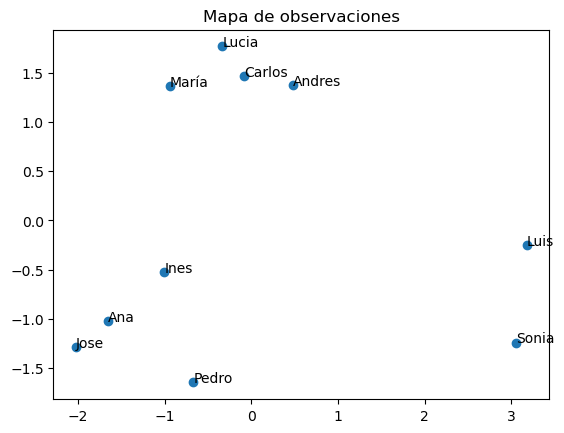

In [44]:
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]
z = df.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x,y)

# Agregar los nombres
for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [52]:
componentes_2 = pd.DataFrame(data = modelo_pca.components_,
                          columns = df.columns,
                          index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
componetes_2 = componentes_2.iloc[0:2, :]
# Rotamos el resultado
componetes_2 = componetes_2.T
componetes_2

,PC1,PC2
Matematicas,-0.525566,-0.274989
Ciencias,-0.422668,-0.511731
Español,-0.361602,0.559163
Historia,-0.355195,0.584408
EdFisica,0.536854,0.091191


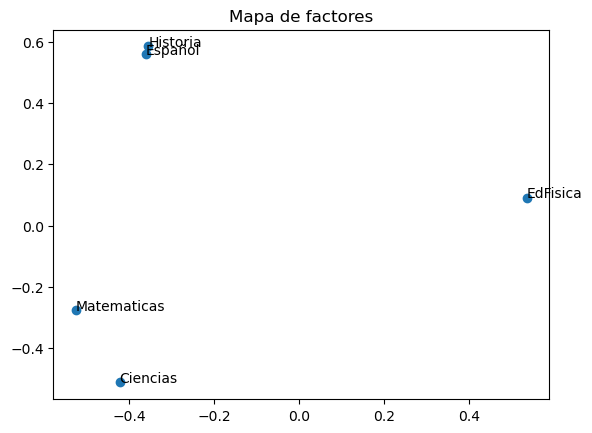

In [56]:
# Anlisis de factores
x = componetes_2.iloc[:,0]
y = componetes_2.iloc[:,1]
z = componetes_2.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x,y)

# Agregar los nombres
for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [58]:
# Procedimeinto para obtener la matriz estandarizada original
original = np.dot(modelo_pca.components_.T, proyecciones.T)
original = original.T
print(original)

[[ 0.23263076 -0.7529862   1.78848525  0.65792263  0.65465367]
 [ 0.78651352  1.14584856 -0.53899555 -0.84590053 -0.49386154]
 [ 0.89729007  1.01489444  0.31849737  0.09398895  0.08039606]
 [-1.98290027 -0.7529862  -1.51898747 -0.84590053  1.80316888]
 [-0.87513476 -1.0803715   0.07349939  0.93988948 -0.14930698]
 [ 1.11884317  1.27680268 -0.0489996   0.09398895 -0.95326763]
 [-0.5428051  -0.81846326  0.56349535  1.03387842 -0.2641585 ]
 [ 1.22961972  1.34227974 -0.29399757  0.09398895 -1.64237675]
 [-0.87513476 -1.0803715  -1.51898747 -2.25573474  1.45861432]
 [ 0.01107766 -0.29464677  1.1759903   1.03387842 -0.49386154]]
